In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [99]:
df=pd.read_csv("C:/Users/JADESOLA/Downloads/Student_performance_data _.csv")

In [100]:
df.shape

(2392, 15)

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [102]:
main_df = pd.concat([df.head(25), df.tail(25)])


In [103]:
main_df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='str')

In [104]:
#Drop colums that are not relevant to the analysis

main_df.drop("GradeClass", axis=1, inplace=True)
main_df.drop("Age", axis = 1, inplace=True)
main_df.drop("Gender", axis = 1, inplace=True)
main_df.drop("Ethnicity", axis = 1, inplace=True)
main_df.drop("StudentID", axis=1,inplace=True)
main_df.drop("Sports", axis = 1, inplace=True)
main_df.drop("Music", axis = 1, inplace=True)
main_df.drop("Volunteering", axis = 1, inplace=True)

In [105]:
print(main_df)

      ParentalEducation  StudyTimeWeekly  Absences  Tutoring  ParentalSupport  \
0                     2        19.833723         7         1                2   
1                     1        15.408756         0         0                1   
2                     3         4.210570        26         0                2   
3                     3        10.028829        14         0                3   
4                     2         4.672495        17         1                3   
5                     1         8.191219         0         0                1   
6                     1        15.601680        10         0                3   
7                     4        15.424496        22         1                1   
8                     0         4.562008         1         0                2   
9                     1        18.444466         0         0                3   
10                    1        11.851364        11         0                1   
11                    1     

In [106]:
print(main_df)

      ParentalEducation  StudyTimeWeekly  Absences  Tutoring  ParentalSupport  \
0                     2        19.833723         7         1                2   
1                     1        15.408756         0         0                1   
2                     3         4.210570        26         0                2   
3                     3        10.028829        14         0                3   
4                     2         4.672495        17         1                3   
5                     1         8.191219         0         0                1   
6                     1        15.601680        10         0                3   
7                     4        15.424496        22         1                1   
8                     0         4.562008         1         0                2   
9                     1        18.444466         0         0                3   
10                    1        11.851364        11         0                1   
11                    1     

In [107]:
main_df.info()


<class 'pandas.DataFrame'>
Index: 50 entries, 0 to 2391
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ParentalEducation  50 non-null     int64  
 1   StudyTimeWeekly    50 non-null     float64
 2   Absences           50 non-null     int64  
 3   Tutoring           50 non-null     int64  
 4   ParentalSupport    50 non-null     int64  
 5   Extracurricular    50 non-null     int64  
 6   GPA                50 non-null     float64
dtypes: float64(2), int64(5)
memory usage: 3.1 KB


In [108]:
#Round up the StudyTimeWeekly and GPA columns to make the plot neater

main_df["StudyTimeWeekly"] = main_df["StudyTimeWeekly"].round(0)
main_df["Extracurricular"] = main_df["Extracurricular"].map ({
    0: "No",
    1: "Yes"
})

main_df["Tutoring"] = main_df["Tutoring"].map ({
    0: "No",
    1: "Yes"
})

# main_df["GPA"] = main_df["GPA"].round(1)

In [109]:
print(main_df)

      ParentalEducation  StudyTimeWeekly  Absences Tutoring  ParentalSupport  \
0                     2             20.0         7      Yes                2   
1                     1             15.0         0       No                1   
2                     3              4.0        26       No                2   
3                     3             10.0        14       No                3   
4                     2              5.0        17      Yes                3   
5                     1              8.0         0       No                1   
6                     1             16.0        10       No                3   
7                     4             15.0        22      Yes                1   
8                     0              5.0         1       No                2   
9                     1             18.0         0       No                3   
10                    1             12.0        11       No                1   
11                    1              8.0

<BarContainer object of 50 artists>

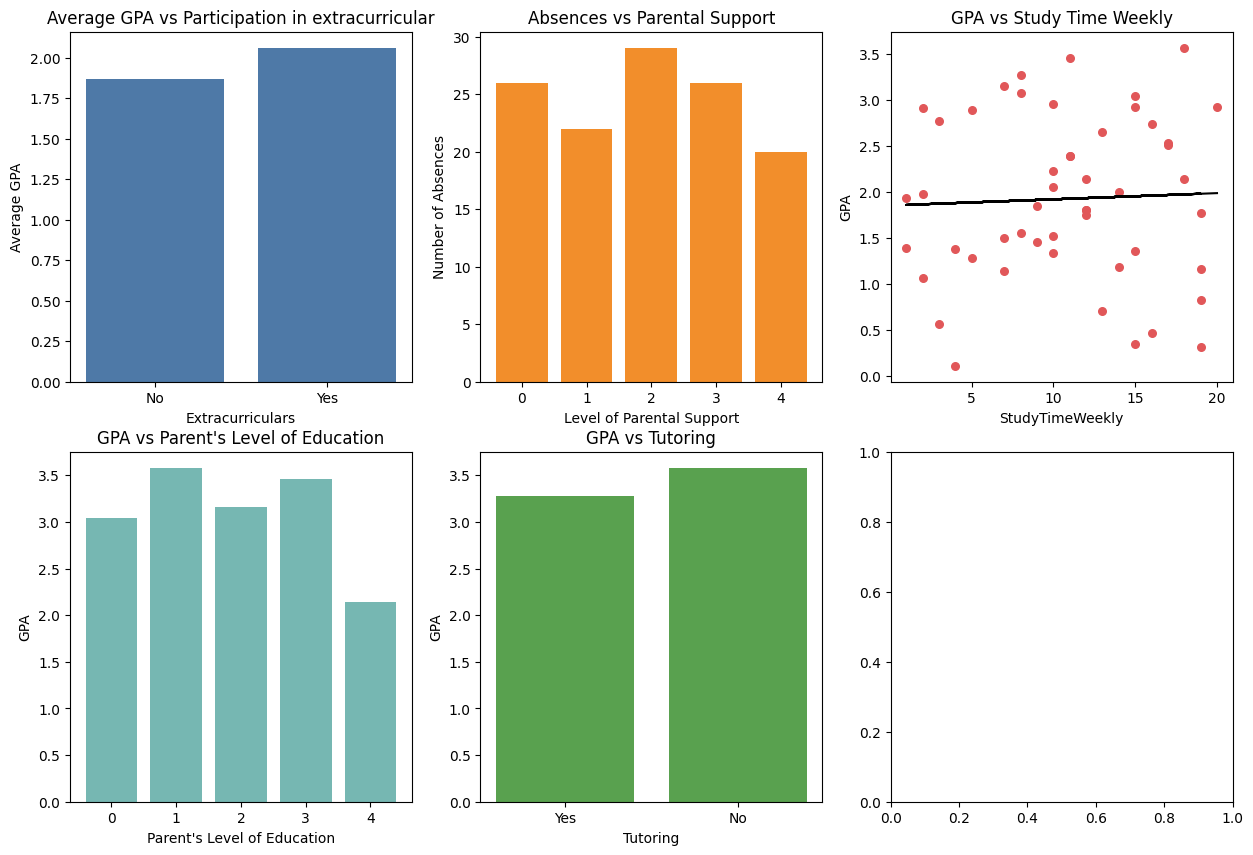

In [111]:
#plot the graph to show relationship between the columns
fig,axs = plt.subplots(2,3, figsize=(15,10))

colours = ["red", "orange","yellow", "green", "blue", "indigo", "violet"]
ParentalSupportPalette= (main_df["ParentalSupport"].max())
avg_gpa = main_df.groupby("Extracurricular")["GPA"].mean()

#First figure: Barpplot showing how participation in extracurricular after students' academic performance
axs[0,0].bar(avg_gpa.index, avg_gpa.values, color = "#4E79A7")
axs[0,0].set_title("Average GPA vs Participation in extracurricular")
axs[0,0].set_xlabel("Extracurriculars")
axs[0,0].set_ylabel("Average GPA")

#Second figure: Lineplot showing how the rating of Parental Support the student has affects the number of absences the student has
sort_ParentalSupport = main_df.sort_values("ParentalSupport")
axs[0,1].bar(sort_ParentalSupport["ParentalSupport"], main_df["Absences"], color = "#F28E2B" )
axs[0,1].set_title("Absences vs Parental Support")
axs[0,1].set_xlabel("Level of Parental Support")
axs[0,1].set_ylabel("Number of Absences")

#Third figure: Scatterplot show how the Study Time Per Week affects the Students' GPAs
axs[0,2].scatter(main_df["StudyTimeWeekly"], main_df["GPA"], color = "#E15759", s = 30)
m, b = np.polyfit(main_df["StudyTimeWeekly"], main_df["GPA"],  1)
axs[0,2].plot(main_df["StudyTimeWeekly"], m*main_df["StudyTimeWeekly"]+ b, color= "black" )
axs[0,2].set_title("GPA vs Study Time Weekly")
axs[0,2].set_ylabel("GPA")
axs[0,2].set_xlabel("StudyTimeWeekly")

#Fourth figure: Line plot showing the how the parent's level of education affects students' GPA
sorted_ParentalEducation = main_df.sort_values("ParentalEducation")
axs[1,0].set_title("GPA vs Parent's Level of Education")
axs[1,0].set_ylabel("GPA")
axs[1,0].set_xlabel("Parent's Level of Education")
axs[1,0].bar(sorted_ParentalEducation["ParentalEducation"], main_df["GPA"], color = "#76B7B2")
# c,d = np.polyfit(main_df["ParentalEducation"], main_df["GPA"],  1)
# axs[1,0].plot(main_df["ParentalEducation"], c*main_df["StudyTimeWeekly"]+ d, color= "black" )

#Fifth figure: Bar plot showing how tutoring affects the academiic perormance of students
axs[1,1].set_title("GPA vs Tutoring")
axs[1,1].set_ylabel("GPA")
axs[1,1].set_xlabel("Tutoring")
axs[1,1].bar(main_df["Tutoring"], main_df["GPA"], color = "#59A14F")
